In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [2]:
df1 = pd.read_csv("BEED_Data.csv")

In [3]:
df1

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,X12,X13,X14,X15,X16,y
0,4,7,18,25,28,27,20,10,-10,-18,-20,-16,13,32,12,10,0
1,87,114,120,106,76,54,28,5,-19,-49,-85,-102,-100,-89,-61,-21,0
2,-131,-133,-140,-131,-123,-108,-58,-51,-70,-77,-76,-76,-73,-57,-40,-14,0
3,68,104,73,34,-12,-26,-38,-36,-67,-88,-25,31,18,-4,6,-29,0
4,-67,-90,-97,-94,-86,-71,-43,-11,23,46,58,50,39,19,-9,-41,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7995,-9,-4,-7,2,-9,-14,-7,12,-5,-3,-2,-2,-12,-5,4,1,3
7996,-8,-4,-7,1,-8,-14,-7,12,-6,-3,-2,-3,-15,-4,4,1,3
7997,-6,-5,-7,1,-8,-14,-7,12,-7,-3,-2,-4,-16,-4,3,1,3
7998,-5,-6,-6,1,-8,-13,-7,13,-7,-2,-3,-5,-15,-4,3,0,3


In [4]:
df1.head()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,X12,X13,X14,X15,X16,y
0,4,7,18,25,28,27,20,10,-10,-18,-20,-16,13,32,12,10,0
1,87,114,120,106,76,54,28,5,-19,-49,-85,-102,-100,-89,-61,-21,0
2,-131,-133,-140,-131,-123,-108,-58,-51,-70,-77,-76,-76,-73,-57,-40,-14,0
3,68,104,73,34,-12,-26,-38,-36,-67,-88,-25,31,18,-4,6,-29,0
4,-67,-90,-97,-94,-86,-71,-43,-11,23,46,58,50,39,19,-9,-41,0


In [5]:
df1.tail()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,X12,X13,X14,X15,X16,y
7995,-9,-4,-7,2,-9,-14,-7,12,-5,-3,-2,-2,-12,-5,4,1,3
7996,-8,-4,-7,1,-8,-14,-7,12,-6,-3,-2,-3,-15,-4,4,1,3
7997,-6,-5,-7,1,-8,-14,-7,12,-7,-3,-2,-4,-16,-4,3,1,3
7998,-5,-6,-6,1,-8,-13,-7,13,-7,-2,-3,-5,-15,-4,3,0,3
7999,-4,-7,-5,2,-8,-12,-7,14,-6,0,-3,-6,-13,-4,2,0,3


In [6]:
df1.columns

Index(['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10', 'X11',
       'X12', 'X13', 'X14', 'X15', 'X16', 'y'],
      dtype='object')

In [7]:
df1.dtypes

X1     int64
X2     int64
X3     int64
X4     int64
X5     int64
X6     int64
X7     int64
X8     int64
X9     int64
X10    int64
X11    int64
X12    int64
X13    int64
X14    int64
X15    int64
X16    int64
y      int64
dtype: object

In [8]:
df1.isnull().sum()

X1     0
X2     0
X3     0
X4     0
X5     0
X6     0
X7     0
X8     0
X9     0
X10    0
X11    0
X12    0
X13    0
X14    0
X15    0
X16    0
y      0
dtype: int64

In [9]:
df1.shape


(8000, 17)

In [10]:
df1["y"].value_counts()

y
0    2000
1    2000
2    2000
3    2000
Name: count, dtype: int64

In [11]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 17 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   X1      8000 non-null   int64
 1   X2      8000 non-null   int64
 2   X3      8000 non-null   int64
 3   X4      8000 non-null   int64
 4   X5      8000 non-null   int64
 5   X6      8000 non-null   int64
 6   X7      8000 non-null   int64
 7   X8      8000 non-null   int64
 8   X9      8000 non-null   int64
 9   X10     8000 non-null   int64
 10  X11     8000 non-null   int64
 11  X12     8000 non-null   int64
 12  X13     8000 non-null   int64
 13  X14     8000 non-null   int64
 14  X15     8000 non-null   int64
 15  X16     8000 non-null   int64
 16  y       8000 non-null   int64
dtypes: int64(17)
memory usage: 1.0 MB


In [12]:
X1 = df1.drop("y", axis=1)
y1 = df1["y"]

In [13]:
X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1, y1, test_size=0.2, random_state=42, stratify=y1
)

In [14]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X1_train, y1_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [15]:
y1_pred_rf = rf_model.predict(X1_test)

In [16]:
print("Accuracy:", accuracy_score(y1_test, y1_pred_rf))
print("\nClassification Report:")
print(classification_report(y1_test, y1_pred_rf))

Accuracy: 0.961875

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       400
           1       0.98      0.98      0.98       400
           2       0.93      0.94      0.94       400
           3       0.94      0.93      0.93       400

    accuracy                           0.96      1600
   macro avg       0.96      0.96      0.96      1600
weighted avg       0.96      0.96      0.96      1600



In [17]:
df2 = pd.read_csv("Epileptic Seizure Recognition.csv")

In [18]:
df2

,Unnamed,X1,X2,X3,X4,X5,X6,X7,X8,X9,...,X170,X171,X172,X173,X174,X175,X176,X177,X178,y
0,X21.V1.791,135,190,229,223,192,125,55,-9,-33,...,-17,-15,-31,-77,-103,-127,-116,-83,-51,4
1,X15.V1.924,386,382,356,331,320,315,307,272,244,...,164,150,146,152,157,156,154,143,129,1
2,X8.V1.1,-32,-39,-47,-37,-32,-36,-57,-73,-85,...,57,64,48,19,-12,-30,-35,-35,-36,5
3,X16.V1.60,-105,-101,-96,-92,-89,-95,-102,-100,-87,...,-82,-81,-80,-77,-85,-77,-72,-69,-65,5
4,X20.V1.54,-9,-65,-98,-102,-78,-48,-16,0,-21,...,4,2,-12,-32,-41,-65,-83,-89,-73,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11495,X22.V1.114,-22,-22,-23,-26,-36,-42,-45,-42,-45,...,15,16,12,5,-1,-18,-37,-47,-48,2
11496,X19.V1.354,-47,-11,28,77,141,211,246,240,193,...,-65,-33,-7,14,27,48,77,117,170,1
11497,X8.V1.28,14,6,-13,-16,10,26,27,-9,4,...,-65,-48,-61,-62,-67,-30,-2,-1,-8,5
11498,X10.V1.932,-40,-25,-9,-12,-2,12,7,19,22,...,121,135,148,143,116,86,68,59,55,3


In [19]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11500 entries, 0 to 11499
Columns: 180 entries, Unnamed to y
dtypes: int64(179), object(1)
memory usage: 15.8+ MB


In [20]:
df2.columns

Index(['Unnamed', 'X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9',
       ...
       'X170', 'X171', 'X172', 'X173', 'X174', 'X175', 'X176', 'X177', 'X178',
       'y'],
      dtype='object', length=180)

In [21]:
df2["y"].value_counts()

y
4    2300
1    2300
5    2300
2    2300
3    2300
Name: count, dtype: int64

In [22]:
df2 = df2.drop("Unnamed", axis=1)

In [23]:
df2.isnull().sum()

X1      0
X2      0
X3      0
X4      0
X5      0
       ..
X175    0
X176    0
X177    0
X178    0
y       0
Length: 179, dtype: int64

In [24]:
X2 = df2.drop("y", axis=1)
y2 = df2["y"]

In [25]:
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42, stratify=y2
)

In [26]:
scaler2 = StandardScaler()

X2_train_scaled = scaler2.fit_transform(X2_train)
X2_test_scaled = scaler2.transform(X2_test)

In [27]:
rf_model2 = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model2.fit(X2_train, y2_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [28]:
y2_pred_rf = rf_model2.predict(X2_test)

In [29]:
print("Accuracy:", accuracy_score(y2_test, y2_pred_rf))
print("\nClassification Report:")
print(classification_report(y2_test, y2_pred_rf))

Accuracy: 0.7060869565217391

Classification Report:
              precision    recall  f1-score   support

           1       0.93      0.97      0.95       460
           2       0.62      0.56      0.59       460
           3       0.59      0.54      0.57       460
           4       0.74      0.76      0.75       460
           5       0.62      0.70      0.66       460

    accuracy                           0.71      2300
   macro avg       0.70      0.71      0.70      2300
weighted avg       0.70      0.71      0.70      2300



In [30]:
scaler1 = StandardScaler()

X1_train_scaled = scaler1.fit_transform(X1_train)
X1_test_scaled = scaler1.transform(X1_test)

In [31]:
svm_model1 = SVC(kernel="rbf")
svm_model1.fit(X1_train_scaled, y1_train)


,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [32]:
y1_pred_svm = svm_model1.predict(X1_test_scaled)

In [33]:
print("Accuracy:", accuracy_score(y1_test, y1_pred_svm))
print("\nClassification Report:")
print(classification_report(y1_test, y1_pred_svm))

Accuracy: 0.744375

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99       400
           1       0.81      0.71      0.76       400
           2       0.57      0.93      0.70       400
           3       0.72      0.35      0.47       400

    accuracy                           0.74      1600
   macro avg       0.77      0.74      0.73      1600
weighted avg       0.77      0.74      0.73      1600



In [34]:
svm_model2 = SVC(kernel="rbf")
svm_model2.fit(X2_train_scaled, y2_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [35]:
y2_pred_svm = svm_model2.predict(X2_test_scaled)

In [36]:
print("Accuracy:", accuracy_score(y2_test, y2_pred_svm))
print("\nClassification Report:")
print(classification_report(y2_test, y2_pred_svm))

Accuracy: 0.5652173913043478

Classification Report:
              precision    recall  f1-score   support

           1       0.94      0.95      0.94       460
           2       0.39      0.19      0.26       460
           3       0.50      0.26      0.34       460
           4       0.83      0.53      0.64       460
           5       0.38      0.90      0.54       460

    accuracy                           0.57      2300
   macro avg       0.61      0.57      0.54      2300
weighted avg       0.61      0.57      0.54      2300



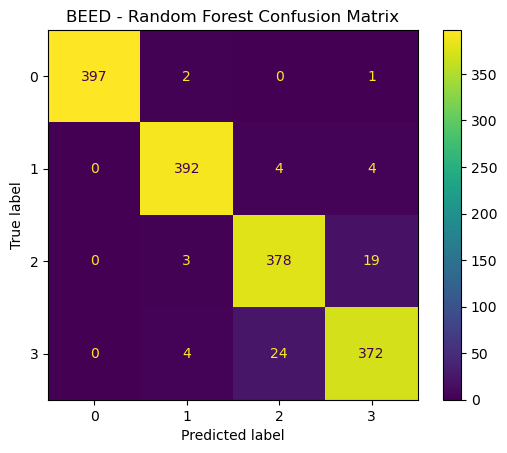

In [37]:
cm_beed_rf = confusion_matrix(y1_test, y1_pred_rf)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_beed_rf,
    display_labels=rf_model.classes_
)

disp.plot()
plt.title("BEED - Random Forest Confusion Matrix")
plt.show()

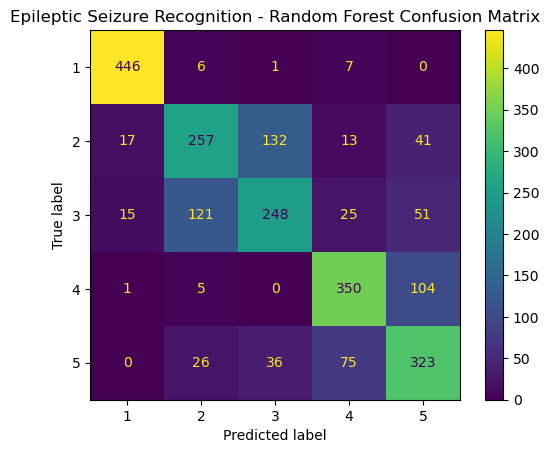

In [38]:
cm_esr_rf = confusion_matrix(y2_test, y2_pred_rf)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_esr_rf,
    display_labels=rf_model2.classes_
)

disp.plot()
plt.title("Epileptic Seizure Recognition - Random Forest Confusion Matrix")
plt.show()

In [39]:
feature_importance_beed = pd.Series(
    rf_model.feature_importances_,
    index=X1.columns
).sort_values(ascending=False)

feature_importance_beed

X8     0.123396
X16    0.099838
X11    0.079017
X6     0.068173
X12    0.064780
X15    0.063852
X7     0.062401
X10    0.058099
X1     0.054894
X14    0.053873
X9     0.052344
X3     0.047449
X4     0.046850
X2     0.046544
X5     0.041040
X13    0.037452
dtype: float64

In [40]:
feature_importance_esr = pd.Series(
    rf_model2.feature_importances_,
    index=X2.columns
).sort_values(ascending=False)

feature_importance_esr.head(10)

X158    0.010160
X156    0.009037
X39     0.008788
X44     0.008670
X157    0.008668
X160    0.008501
X106    0.008283
X159    0.008160
X38     0.007670
X33     0.007666
dtype: float64

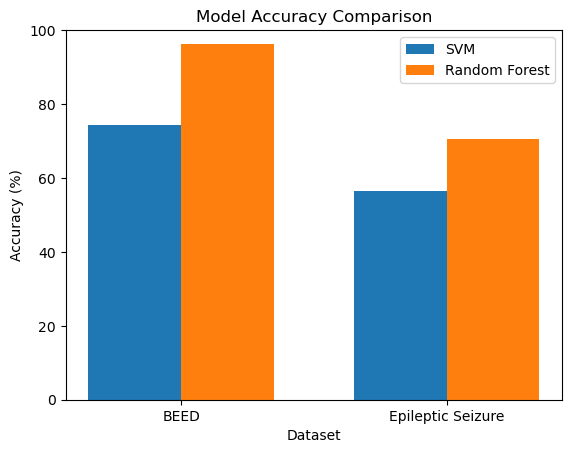

In [41]:
import matplotlib.pyplot as plt

datasets = ["BEED", "Epileptic Seizure"]
svm_accuracy = [74.44, 56.52]
rf_accuracy = [96.19, 70.61]

x = range(len(datasets))
width = 0.35

plt.bar([i - width/2 for i in x], svm_accuracy, width, label="SVM")
plt.bar([i + width/2 for i in x], rf_accuracy, width, label="Random Forest")

plt.ylabel("Accuracy (%)")
plt.xlabel("Dataset")
plt.title("Model Accuracy Comparison")
plt.xticks(list(x), datasets)
plt.ylim(0, 100)
plt.legend()
plt.show()

In [42]:
results = pd.DataFrame({
    "Dataset": [
        "BEED",
        "BEED",
        "Epileptic Seizure Recognition",
        "Epileptic Seizure Recognition"
    ],
    "Model": [
        "SVM",
        "Random Forest",
        "SVM",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y1_test, y1_pred_svm),
        accuracy_score(y1_test, y1_pred_rf),
        accuracy_score(y2_test, y2_pred_svm),
        accuracy_score(y2_test, y2_pred_rf)
    ],
    "Macro F1": [
        classification_report(y1_test, y1_pred_svm, output_dict=True)["macro avg"]["f1-score"],
        classification_report(y1_test, y1_pred_rf, output_dict=True)["macro avg"]["f1-score"],
        classification_report(y2_test, y2_pred_svm, output_dict=True)["macro avg"]["f1-score"],
        classification_report(y2_test, y2_pred_rf, output_dict=True)["macro avg"]["f1-score"]
    ]
})

results

,Dataset,Model,Accuracy,Macro F1
0,BEED,SVM,0.744375,0.731021
1,BEED,Random Forest,0.961875,0.961913
2,Epileptic Seizure Recognition,SVM,0.565217,0.544349
3,Epileptic Seizure Recognition,Random Forest,0.706087,0.703097


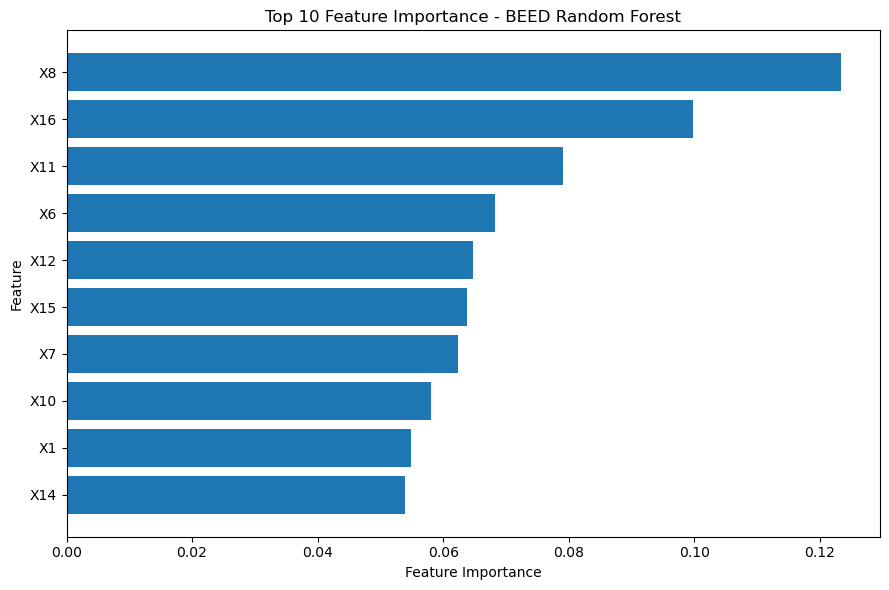

In [43]:
# Get the top 10 most important features
top10_beed = feature_importance_beed.head(10).sort_values(ascending=True)

plt.figure(figsize=(9, 6))
plt.barh(top10_beed.index, top10_beed.values)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importance - BEED Random Forest")

plt.tight_layout()
plt.show()

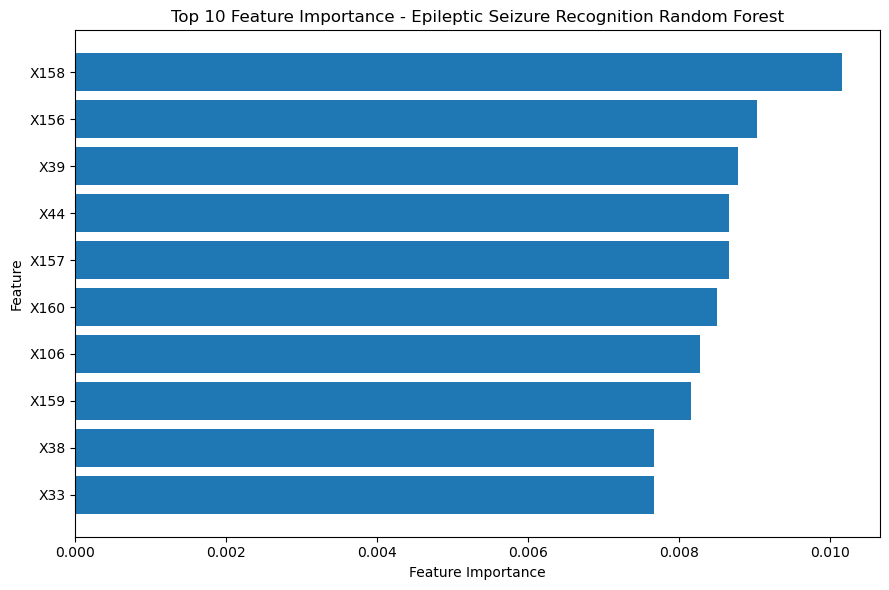

In [44]:
# Get the top 10 most important features
top10_esr = feature_importance_esr.head(10).sort_values(ascending=True)

plt.figure(figsize=(9, 6))
plt.barh(top10_esr.index, top10_esr.values)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importance - Epileptic Seizure Recognition Random Forest")

plt.tight_layout()
plt.show()

## Task 2 Part 2- Cross-Validation

In [45]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

In [46]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores_beed = cross_val_score(
    RandomForestClassifier(n_estimators=100, random_state=42),
    X1_train,
    y1_train,
    cv=cv,
    scoring="accuracy"
)

print("BEED 5-Fold Cross-Validation Accuracy:")
print(cv_scores_beed)

print("Mean Accuracy:", cv_scores_beed.mean())
print("Standard Deviation:", cv_scores_beed.std())

BEED 5-Fold Cross-Validation Accuracy:
[0.9453125  0.9484375  0.9671875  0.95390625 0.96640625]
Mean Accuracy: 0.95625
Standard Deviation: 0.009043622580304857


In [47]:
cv_scores_esr = cross_val_score(
    RandomForestClassifier(n_estimators=100, random_state=42),
    X2_train,
    y2_train,
    cv=cv,
    scoring="accuracy"
)

print("Epileptic Seizure Recognition 5-Fold Cross-Validation Accuracy:")
print(cv_scores_esr)

print("Mean Accuracy:", cv_scores_esr.mean())
print("Standard Deviation:", cv_scores_esr.std())

Epileptic Seizure Recognition 5-Fold Cross-Validation Accuracy:
[0.69021739 0.67826087 0.66902174 0.69402174 0.67663043]
Mean Accuracy: 0.6816304347826087
Standard Deviation: 0.009193621936430628


## Learning Curve


In [48]:
from sklearn.model_selection import learning_curve
import numpy as np

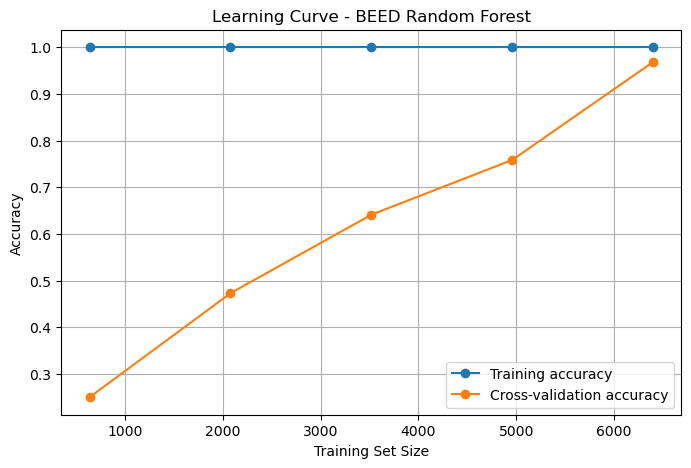

In [49]:
rf_beed_lc = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

train_sizes_beed, train_scores_beed, val_scores_beed = learning_curve(
    rf_beed_lc,
    X1,
    y1,
    cv=cv,
    scoring="accuracy",
    train_sizes=np.linspace(0.1, 1.0, 5),
    n_jobs=-1
)

train_mean_beed = train_scores_beed.mean(axis=1)
val_mean_beed = val_scores_beed.mean(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes_beed, train_mean_beed, marker="o", label="Training accuracy")
plt.plot(train_sizes_beed, val_mean_beed, marker="o", label="Cross-validation accuracy")

plt.xlabel("Training Set Size")
plt.ylabel("Accuracy")
plt.title("Learning Curve - BEED Random Forest")
plt.legend()
plt.grid(True)
plt.show()

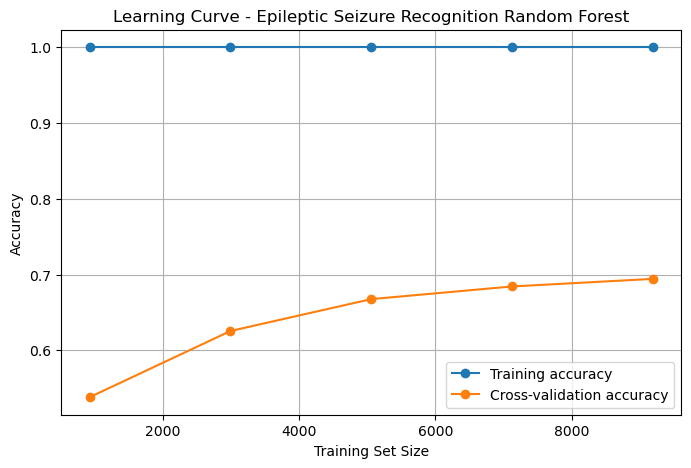

In [63]:
rf_esr_lc = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

train_sizes_esr, train_scores_esr, val_scores_esr = learning_curve(
    rf_esr_lc,
    X2,
    y2,
    cv=cv,
    scoring="accuracy",
    train_sizes=np.linspace(0.1, 1.0, 5),
    n_jobs=-1
)

train_mean_esr = train_scores_esr.mean(axis=1)
val_mean_esr = val_scores_esr.mean(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes_esr, train_mean_esr, marker="o", label="Training accuracy")
plt.plot(train_sizes_esr, val_mean_esr, marker="o", label="Cross-validation accuracy")

plt.xlabel("Training Set Size")
plt.ylabel("Accuracy")
plt.title("Learning Curve - Epileptic Seizure Recognition Random Forest")
plt.legend()
plt.grid(True)
plt.show()

In [51]:
print("BEED columns:")
print(X1.columns.tolist())

print("\nEpileptic Seizure Recognition columns:")
print(X2.columns.tolist())

BEED columns:
['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10', 'X11', 'X12', 'X13', 'X14', 'X15', 'X16']

Epileptic Seizure Recognition columns:
['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10', 'X11', 'X12', 'X13', 'X14', 'X15', 'X16', 'X17', 'X18', 'X19', 'X20', 'X21', 'X22', 'X23', 'X24', 'X25', 'X26', 'X27', 'X28', 'X29', 'X30', 'X31', 'X32', 'X33', 'X34', 'X35', 'X36', 'X37', 'X38', 'X39', 'X40', 'X41', 'X42', 'X43', 'X44', 'X45', 'X46', 'X47', 'X48', 'X49', 'X50', 'X51', 'X52', 'X53', 'X54', 'X55', 'X56', 'X57', 'X58', 'X59', 'X60', 'X61', 'X62', 'X63', 'X64', 'X65', 'X66', 'X67', 'X68', 'X69', 'X70', 'X71', 'X72', 'X73', 'X74', 'X75', 'X76', 'X77', 'X78', 'X79', 'X80', 'X81', 'X82', 'X83', 'X84', 'X85', 'X86', 'X87', 'X88', 'X89', 'X90', 'X91', 'X92', 'X93', 'X94', 'X95', 'X96', 'X97', 'X98', 'X99', 'X100', 'X101', 'X102', 'X103', 'X104', 'X105', 'X106', 'X107', 'X108', 'X109', 'X110', 'X111', 'X112', 'X113', 'X114', 'X115', 'X116', 'X117', 'X118', 'X119

In [52]:
!pip install fairlearn

In [53]:
from fairlearn.metrics import MetricFrame
from sklearn.metrics import accuracy_score

In [54]:
metric_beed = MetricFrame(
    metrics=accuracy_score,
    y_true=y1_test,
    y_pred=y1_pred_rf,
    sensitive_features=y1_test
)

print("BEED accuracy by class:")
print(metric_beed.by_group)


BEED accuracy by class:
y
0    0.9925
1    0.9800
2    0.9450
3    0.9300
Name: accuracy_score, dtype: float64


In [55]:
metric_esr = MetricFrame(
    metrics=accuracy_score,
    y_true=y2_test,
    y_pred=y2_pred_rf,
    sensitive_features=y2_test
)

print("Epileptic Seizure Recognition accuracy by class:")
print(metric_esr.by_group)

Epileptic Seizure Recognition accuracy by class:
y
1    0.969565
2    0.558696
3    0.539130
4    0.760870
5    0.702174
Name: accuracy_score, dtype: float64


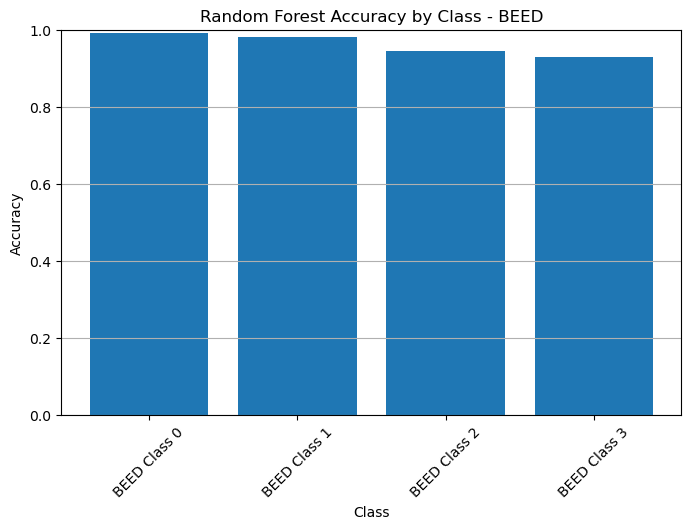

In [56]:
beed_class_accuracy = metric_beed.by_group
esr_class_accuracy = metric_esr.by_group

plt.figure(figsize=(8, 5))

plt.bar(
    [f"BEED Class {x}" for x in beed_class_accuracy.index],
    beed_class_accuracy.values
)

plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.xlabel("Class")
plt.title("Random Forest Accuracy by Class - BEED")
plt.xticks(rotation=45)
plt.grid(axis="y")

plt.show()

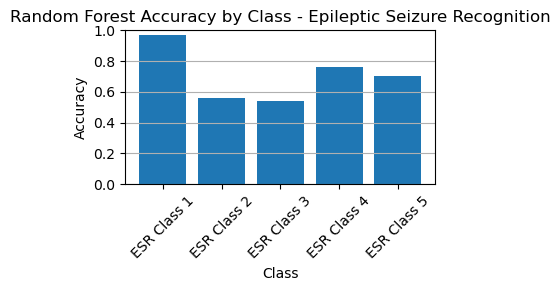

In [57]:
plt.figure(figsize=(4, 2))

plt.bar(
    [f"ESR Class {x}" for x in esr_class_accuracy.index],
    esr_class_accuracy.values
)

plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.xlabel("Class")
plt.title("Random Forest Accuracy by Class - Epileptic Seizure Recognition")
plt.xticks(rotation=45)
plt.grid(axis="y")

plt.show()

##  Security, Privacy and Ethical Risks

In [58]:
print("BEED class distribution:")
print(y1.value_counts().sort_index())

print("\nEpileptic Seizure Recognition class distribution:")
print(y2.value_counts().sort_index())

BEED class distribution:
y
0    2000
1    2000
2    2000
3    2000
Name: count, dtype: int64

Epileptic Seizure Recognition class distribution:
y
1    2300
2    2300
3    2300
4    2300
5    2300
Name: count, dtype: int64
